# GO robustness across the 3 windows × 2 percentiles grid

Reviewer major comment 5 asked for sensitivity analyses at alternative window sizes (5 kb and
20 kb) **and** alternative percentiles (10 %). Those were answered separately: window size in
`05b_window_sensitivity.py` (enrichment odds ratios) and percentile in
`05c_percentile_sensitivity.py` (GO terms at 10 kb only). Four of the six cells of the grid —
5 kb and 20 kb at either percentile — had never had GO run at all, so the robustness statement
in the Results was narrower than it read, and the headline-claim table honestly said
`not evaluated` in its window columns.

`07b_go_grid.py` filled the grid by calling the existing gene-set builders with a different
per-window gene table from `07a_build_gene_tables.py`, so no third copy of the construction
exists and a window effect cannot be confused with a construction artefact. This notebook is
the comparison: **10 kb / 5 %, the published cell, against all five alternatives**, at all
three GO levels, using the same measures the existing robustness section uses so the two read
as one analysis.

**What a window effect here is, and is not.** The grid is GO only — the enrichment odds ratios
at 5 kb and 20 kb come from `05b`, and no permutations were re-run. So a difference between
grid cells is a **gene-set** effect (a wider window changes which genes are in the top 5 %),
not a background effect. The Results text says so explicitly (edit M4) so the two analyses are
not conflated.

**Writes** `svg/S12A…S12C_*.svg` → new Supplementary Figure S12, and four tables. The
headline-claim grid deliberately does **not** get an S12 panel: it feeds `nb05`'s S13D, which
becomes the six-condition version of the panel it already was (decision D-b), rather than a
second figure of the same thing.

In [1]:
import itertools
import json
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy import stats

sys.path.insert(0, os.path.abspath("."))
import revision_lib as rl

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams.update({"font.size": rl.GLOBAL_FONT_SIZE})
os.makedirs(rl.SVG_DIR, exist_ok=True)

OUT = rl.OUTPUT_DIR
GRID = os.path.join(OUT, "GO_grid")

WINDOWS = ["5kb", "10kb", "20kb"]
PERCENTILES = [5, 10]
LEVELS = ["classes_count", "classes_divergence", "families"]
LEVEL_LABEL = {"classes_count": "TE groups by element count",
               "classes_divergence": "TE groups by divergence",
               "families": "TE families"}
GROUP_COLUMN = {"classes_count": "class_name", "classes_divergence": "class_name",
                "families": "family_name"}
PUBLISHED = ("10kb", 5)
CONDITIONS = [(w, p) for w in WINDOWS for p in PERCENTILES]

N_CONCORDANCE_PERMUTATIONS = 1000
RANDOM_SEED = 42

index = pd.read_csv(os.path.join(GRID, "INDEX.csv"))
manifest = json.load(open(os.path.join(GRID, "MANIFEST.json")))
print(f"grid: {len(index)} of {len(CONDITIONS) * len(LEVELS)} cells")
missing = [(lvl, w, p) for lvl in LEVELS for w, p in CONDITIONS
           if index[(index.level == lvl) & (index.window == w)
                    & (index.percentile == p)].empty]
assert not missing, f"grid is incomplete: {missing}"
print("builders:", json.dumps(manifest["builders"], indent=2))

grid: 18 of 18 cells
builders: {
  "5pct/classes_count": "06_go_rerun_fdr005.run_level_classes_count",
  "5pct/classes_divergence": "06_go_rerun_fdr005.run_level_classes_divergence",
  "5pct/families": "06_go_rerun_fdr005.run_level_families",
  "10pct/classes_count": "05c_percentile_sensitivity.build_classes_count",
  "10pct/classes_divergence": "05c_percentile_sensitivity.build_classes_divergence",
  "10pct/families": "05c_percentile_sensitivity.build_families"
}


## 1. Loading the grid

Every cell is read from its **published** file (FDR < 0.05), which is what any statement about
the grid must be based on. The `_fdr01_reference` twin is read only for the headline-claim
lookup in section 4, where an FDR above 0.05 still has to be reportable — a claim that fails
in a cell needs its actual p-value shown, not a blank.

`group` is the class or family name, extended with the divergence direction where the level has
one, exactly as `05c_percentile_sensitivity.py` builds it — so the two analyses key on the same
labels.

In [2]:
def group_key(table, level):
    """One label per GO study — class, family, or class + divergence direction."""
    column = GROUP_COLUMN[level]
    if "divergence_group" in table.columns:
        return table[column].astype(str) + " / " + table["divergence_group"].astype(str)
    return table[column].astype(str)


def read_cell(level, window, pct, reference=False):
    suffix = "fdr01_reference" if reference else "fdr005"
    path = os.path.join(GRID, f"GO_{level}_{window}_p{pct}_{suffix}.csv")
    table = pd.read_csv(path, low_memory=False)
    table["group"] = group_key(table, level)
    return table


cells = {(level, window, pct): read_cell(level, window, pct)
         for level in LEVELS for window, pct in CONDITIONS}
for level in LEVELS:
    if not cells[(level, *PUBLISHED)].empty:
        assert cells[(level, *PUBLISHED)].FDR.max() < rl.FDR_THRESHOLD, level
print(f"loaded {len(cells)} cells, all filtered at FDR < {rl.FDR_THRESHOLD}")

term_counts = pd.DataFrame(
    [[len(cells[(level, w, p)]) for w, p in CONDITIONS] for level in LEVELS],
    index=LEVELS, columns=[f"{w}/{p}%" for w, p in CONDITIONS],
)
print()
print(term_counts.to_string())

loaded 18 cells, all filtered at FDR < 0.05

                    5kb/5%  5kb/10%  10kb/5%  10kb/10%  20kb/5%  20kb/10%
classes_count          510      822      425       779      299       544
classes_divergence     209      402      414       632      303       608
families               137      282      140       321      201       402


## 2. Panel S12A — term counts per cell

One 3 × 2 grid per level, annotated with the count and with its ratio to the published cell, so
the direction and the size of every shift is on the artwork. The published cell is outlined.

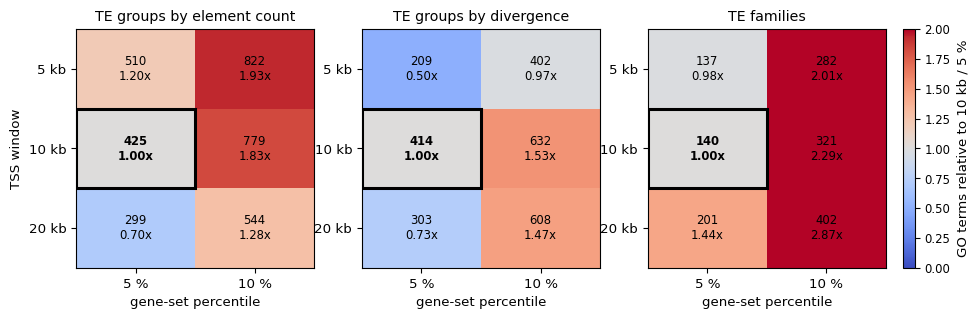

wrote S12A_go_grid_term_counts.svg


In [3]:
fig, axes = plt.subplots(1, len(LEVELS), figsize=(11.0, 3.1))
norm = plt.Normalize(vmin=0, vmax=2.0)
cmap = plt.get_cmap("coolwarm")

for ax, level in zip(axes, LEVELS):
    published_n = len(cells[(level, *PUBLISHED)])
    grid = np.array([[len(cells[(level, w, p)]) for p in PERCENTILES] for w in WINDOWS])
    ratio = grid / published_n if published_n else np.zeros_like(grid, dtype=float)
    ax.imshow(ratio, cmap=cmap, norm=norm, aspect="auto")
    for i, w in enumerate(WINDOWS):
        for j, p in enumerate(PERCENTILES):
            is_published = (w, p) == PUBLISHED
            ax.text(j, i, f"{grid[i, j]:,}\n{ratio[i, j]:.2f}x", ha="center",
                    va="center", fontsize=rl.fs(7),
                    fontweight="bold" if is_published else "normal")
            if is_published:
                ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False,
                                           edgecolor="black", linewidth=2.2))
    ax.set_xticks(range(len(PERCENTILES)))
    ax.set_xticklabels([f"{p} %" for p in PERCENTILES], fontsize=rl.fs(8))
    ax.set_yticks(range(len(WINDOWS)))
    ax.set_yticklabels([f"{w[:-2]} kb" for w in WINDOWS], fontsize=rl.fs(8))
    ax.set_title(LEVEL_LABEL[level], fontsize=rl.fs(8.5))
    ax.set_xlabel("gene-set percentile", fontsize=rl.fs(8))
axes[0].set_ylabel("TSS window", fontsize=rl.fs(8))

bar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=axes,
                   fraction=0.03, pad=0.02)
bar.set_label("GO terms relative to 10 kb / 5 %", fontsize=rl.fs(8))
bar.ax.tick_params(labelsize=rl.fs(7))
fig.suptitle("")  # G11: no baked-in title
path = os.path.join(rl.SVG_DIR, "S12A_go_grid_term_counts.svg")
fig.savefig(path, format="svg", transparent=True, bbox_inches="tight")
plt.show()
print(f"wrote {os.path.basename(path)}")

## 3. Panel S12B — how much of the published result survives in each cell

Two measures per cell, both against the published 10 kb / 5 % cell:

* **Jaccard** of the term sets. This is deflated by *gains*: a wider window or a wider
  percentile has more genes and therefore more power, so it finds more terms, and every gain
  lowers Jaccard without anything being lost. It is reported because it is the symmetric
  measure, not because it is the one that answers the reviewer.
* **Fraction of published terms preserved**, which is the measure that answers the reviewer:
  of the terms the paper reports, how many are still significant under this condition.

Both are computed per level over the union of groups, and per group in the table.

In [4]:
def compare_to_published(level, window, pct):
    """Term-set agreement of one cell against the published cell, overall and per group.

    `n_terms` here counts DISTINCT Term IDs, so it is lower than INDEX.csv's
    `n_terms_005`, which counts rows — one per (group, term). A term enriched in three
    groups is three rows there and one term here. Both are right for their purpose:
    rows for "how much output does this cell produce", distinct terms for "is it the
    same biology".
    """
    published = cells[(level, *PUBLISHED)]
    other = cells[(level, window, pct)]
    p_terms, o_terms = set(published["Term ID"]), set(other["Term ID"])
    overall = {
        "level": level,
        "window": window,
        "percentile": pct,
        "is_published": (window, pct) == PUBLISHED,
        "n_terms": len(o_terms),
        "n_terms_published": len(p_terms),
        "n_shared": len(p_terms & o_terms),
        "n_lost": len(p_terms - o_terms),
        "n_gained": len(o_terms - p_terms),
        "jaccard": len(p_terms & o_terms) / len(p_terms | o_terms) if p_terms | o_terms
        else np.nan,
        "fraction_of_published_preserved":
            len(p_terms & o_terms) / len(p_terms) if p_terms else np.nan,
    }

    per_group, term_rows = [], []
    for group in sorted(set(published["group"]) | set(other["group"])):
        g_pub = set(published.loc[published.group == group, "Term ID"])
        g_oth = set(other.loc[other.group == group, "Term ID"])
        per_group.append({
            "level": level, "window": window, "percentile": pct, "group": group,
            "n_terms_published": len(g_pub), "n_terms": len(g_oth),
            "n_shared": len(g_pub & g_oth),
            "jaccard": len(g_pub & g_oth) / len(g_pub | g_oth) if g_pub | g_oth
            else np.nan,
            "fraction_of_published_preserved":
                len(g_pub & g_oth) / len(g_pub) if g_pub else np.nan,
        })
        names = dict(zip(published["Term ID"], published["Term Name"]))
        names.update(dict(zip(other["Term ID"], other["Term Name"])))
        fdr_pub = dict(zip(published["Term ID"], published["FDR"]))
        fdr_oth = dict(zip(other["Term ID"], other["FDR"]))
        for term_id in sorted(g_pub ^ g_oth):
            term_rows.append({
                "level": level, "window": window, "percentile": pct, "group": group,
                "term_id": term_id, "term_name": names.get(term_id, ""),
                "status": "lost" if term_id in g_pub else "gained",
                "fdr_published": fdr_pub.get(term_id), "fdr_cell": fdr_oth.get(term_id),
            })
    return overall, pd.DataFrame(per_group), pd.DataFrame(term_rows)


overall_rows, group_frames, term_frames = [], [], []
for level in LEVELS:
    for window, pct in CONDITIONS:
        overall, per_group, terms = compare_to_published(level, window, pct)
        overall_rows.append(overall)
        group_frames.append(per_group)
        if not terms.empty:
            term_frames.append(terms)

preservation = pd.DataFrame(overall_rows)
preservation_by_group = pd.concat(group_frames, ignore_index=True)
grid_terms = pd.concat(term_frames, ignore_index=True)

preservation.to_csv(os.path.join(OUT, "go_grid_preservation.csv"), index=False)
preservation_by_group.to_csv(os.path.join(OUT, "go_grid_preservation_by_group.csv"),
                             index=False)
grid_terms.to_csv(os.path.join(OUT, "go_grid_terms.csv"), index=False)
print(preservation.drop(columns=["is_published"]).to_string(
    index=False, float_format=lambda v: f"{v:.3f}"))
print(f"\n{len(grid_terms):,} term changes written to go_grid_terms.csv")

             level window  percentile  n_terms  n_terms_published  n_shared  n_lost  n_gained  jaccard  fraction_of_published_preserved
     classes_count    5kb           5      465                375       293      82       172    0.536                            0.781
     classes_count    5kb          10      728                375       333      42       395    0.432                            0.888
     classes_count   10kb           5      375                375       375       0         0    1.000                            1.000
     classes_count   10kb          10      670                375       340      35       330    0.482                            0.907
     classes_count   20kb           5      249                375       207     168        42    0.496                            0.552
     classes_count   20kb          10      419                375       254     121       165    0.470                            0.677
classes_divergence    5kb           5      183  

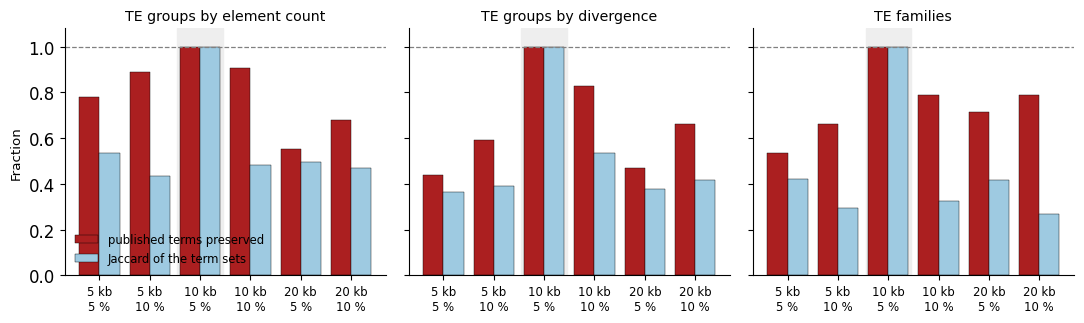

wrote S12B_go_grid_preservation.svg


In [5]:
fig, axes = plt.subplots(1, len(LEVELS), figsize=(11.0, 3.4), sharey=True)
labels = [f"{w[:-2]} kb\n{p} %" for w, p in CONDITIONS]
positions = np.arange(len(CONDITIONS))

for ax, level in zip(axes, LEVELS):
    part = preservation[preservation.level == level].set_index(["window", "percentile"])
    preserved = [part.loc[(w, p), "fraction_of_published_preserved"]
                 for w, p in CONDITIONS]
    jaccard = [part.loc[(w, p), "jaccard"] for w, p in CONDITIONS]
    ax.bar(positions - 0.2, preserved, width=0.4, color="#ab1f20",
           edgecolor="black", linewidth=0.3, label="published terms preserved")
    ax.bar(positions + 0.2, jaccard, width=0.4, color="#9ecae1",
           edgecolor="black", linewidth=0.3, label="Jaccard of the term sets")
    for i, (w, p) in enumerate(CONDITIONS):
        if (w, p) == PUBLISHED:
            ax.axvspan(i - 0.45, i + 0.45, color="#eeeeee", zorder=0)
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontsize=rl.fs(7))
    ax.set_ylim(0, 1.08)
    ax.axhline(1.0, color="grey", ls="--", lw=0.9)
    ax.set_title(LEVEL_LABEL[level], fontsize=rl.fs(8.5))
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Fraction", fontsize=rl.fs(8))
axes[0].legend(frameon=False, fontsize=rl.fs(7), loc="lower left")
fig.tight_layout()
path = os.path.join(rl.SVG_DIR, "S12B_go_grid_preservation.svg")
fig.savefig(path, format="svg", transparent=True, bbox_inches="tight")
plt.show()
print(f"wrote {os.path.basename(path)}")

## 4. The headline claims under all six conditions

This is the table whose window columns previously read `not evaluated`. The claims are
`05c_percentile_sensitivity.py`'s `HEADLINE_CLAIMS` list, imported rather than retyped so the
two tables cannot drift apart, and each is looked up in every cell.

The lookup reads the `_fdr01_reference` file so a claim that fails under a condition still
reports the FDR it reached, rather than an uninformative blank. `survives` is always judged at
FDR < 0.05.

This table feeds `nb05`'s panel S13D (decision D-b).

In [6]:
import importlib

percentile_module = importlib.import_module("05c_percentile_sensitivity")
HEADLINE_CLAIMS = percentile_module.HEADLINE_CLAIMS
print(f"{len(HEADLINE_CLAIMS)} headline claims x {len(CONDITIONS)} conditions")

reference_cells = {(level, w, p): read_cell(level, w, p, reference=True)
                   for level in LEVELS for w, p in CONDITIONS}

rows = []
for level, group, term in HEADLINE_CLAIMS:
    record = {"level": level, "group": group, "term_name": term}
    for window, pct in CONDITIONS:
        table = reference_cells[(level, window, pct)]
        # 'LINE' matches both 'LINE / highest' and 'LINE / lowest'; the claim is about
        # the class, so the strongest of its divergence groups is taken — as 05c does.
        hit = table[table["group"].str.startswith(group) & (table["Term Name"] == term)]
        fdr = float(hit["FDR"].min()) if len(hit) else None
        record[f"fdr_{window}_p{pct}"] = fdr
        record[f"survives_{window}_p{pct}"] = bool(
            fdr is not None and fdr < rl.FDR_THRESHOLD)
    survived = sum(record[f"survives_{w}_p{p}"] for w, p in CONDITIONS)
    record["n_conditions_survived"] = survived
    record["survives_published"] = record[f"survives_{PUBLISHED[0]}_p{PUBLISHED[1]}"]
    record["verdict"] = ("robust across all six" if survived == len(CONDITIONS)
                         else f"survives {survived} of {len(CONDITIONS)}")
    rows.append(record)

headline = pd.DataFrame(rows)
headline.to_csv(os.path.join(OUT, "go_grid_headline_by_condition.csv"), index=False)
print()
print(headline[["group", "term_name", "n_conditions_survived", "verdict"]]
      .to_string(index=False))
print(f"\nclaims robust across all six conditions: "
      f"{int((headline.n_conditions_survived == len(CONDITIONS)).sum())} of "
      f"{len(headline)}")

9 headline claims x 6 conditions



      group                                      term_name  n_conditions_survived               verdict
       LINE             type I interferon receptor binding                      5       survives 5 of 6
       LINE                    olfactory receptor activity                      6 robust across all six
        SVA termination of RNA polymerase II transcription                      2       survives 2 of 6
         L1                      flavone metabolic process                      6 robust across all six
        MIR                  cellular response to zinc ion                      4       survives 4 of 6
        MIR             intracellular zinc ion homeostasis                      4       survives 4 of 6
hAT-Charlie                    MHC class I protein complex                      1       survives 1 of 6
       LINE                    olfactory receptor activity                      6 robust across all six
       SINE                 mRNA splicing, via spliceosome     

### Where the six-condition claim table is assembled

`robustness_headline_claims_by_condition.csv` mixes GO rows with enrichment rows, and the
enrichment rows come from `05b_window_sensitivity.py` by way of `nb05`. So `nb05` assembles that
file, reading `go_grid_headline_by_condition.csv` written above; this notebook does not write it.
One writer per file — otherwise whichever notebook ran last would decide its contents, and the
`not evaluated` cells the grid was built to fill could silently come back.

Run order is therefore **`07b_go_grid.py` → `nb07` → `nb05`**.

## 5. Panel S12C — which groups keep at least one term

A group with no GO term contributes nothing to any figure, so the count of groups that stay
populated is the coarsest and most robust summary of the grid. Groups are ordered by how many
conditions they survive, so the fragile ones are together at the bottom.

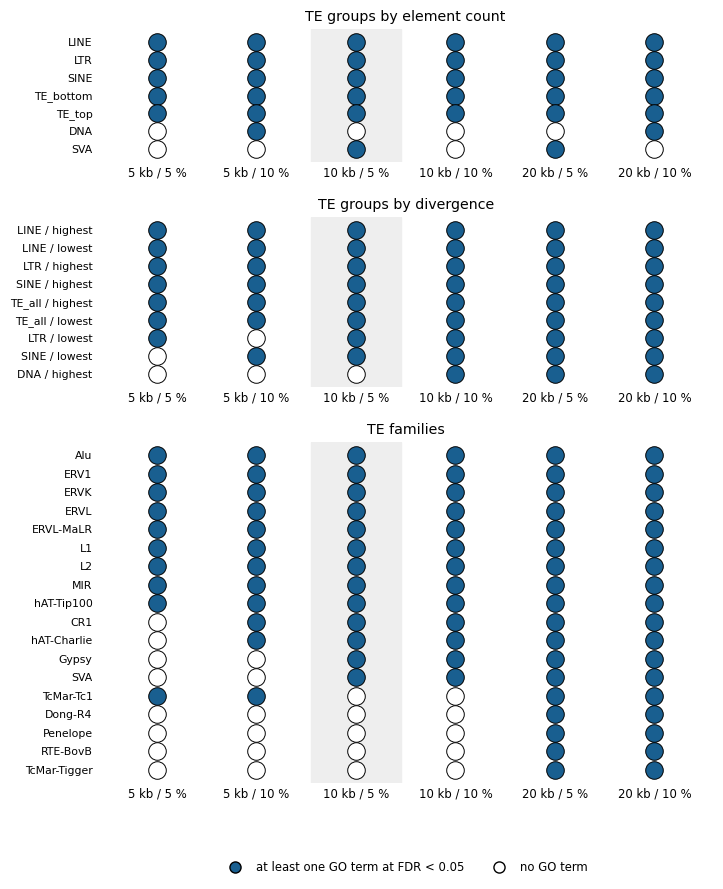

wrote S12C_group_survival.svg and go_grid_group_survival.csv
  classes_count        5 of 7 groups keep a term under all six conditions
  classes_divergence   6 of 9 groups keep a term under all six conditions
  families             9 of 18 groups keep a term under all six conditions


In [7]:
survival_rows = []
for level in LEVELS:
    groups = sorted({g for w, p in CONDITIONS for g in cells[(level, w, p)]["group"]})
    for group in groups:
        record = {"level": level, "group": group}
        for window, pct in CONDITIONS:
            has_terms = (cells[(level, window, pct)]["group"] == group).any()
            record[f"{window}_p{pct}"] = bool(has_terms)
        record["n_conditions"] = sum(record[f"{w}_p{p}"] for w, p in CONDITIONS)
        survival_rows.append(record)
survival = pd.DataFrame(survival_rows)

fig, axes = plt.subplots(
    len(LEVELS), 1, figsize=(7.4, 9.0),
    gridspec_kw={"height_ratios": [max(1, (survival.level == lvl).sum())
                                   for lvl in LEVELS]},
)
for ax, level in zip(axes, LEVELS):
    part = (survival[survival.level == level]
            .sort_values(["n_conditions", "group"], ascending=[False, True]))
    # to_dict("records") and not itertuples(): the condition columns start with a
    # digit ("5kb_p5"), and itertuples renames those to positional _1, _2, ...
    for i, row in enumerate(part.to_dict("records")):
        for j, (window, pct) in enumerate(CONDITIONS):
            present = row[f"{window}_p{pct}"]
            ax.scatter(j, i, s=160,
                       color="#195f90" if present else "white",
                       edgecolor="black", linewidth=0.7, zorder=3)
    ax.set_yticks(range(len(part)))
    ax.set_yticklabels(part["group"], fontsize=rl.fs(6.5))
    ax.set_xticks(range(len(CONDITIONS)))
    ax.set_xticklabels([f"{w[:-2]} kb / {p} %" for w, p in CONDITIONS],
                       fontsize=rl.fs(7))
    ax.set_xlim(-0.6, len(CONDITIONS) - 0.4)
    ax.set_ylim(-0.7, len(part) - 0.3)
    ax.invert_yaxis()
    ax.set_title(LEVEL_LABEL[level], fontsize=rl.fs(8.5))
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(length=0)
    # Mark the published condition so the reader can see which column the paper reports.
    ax.axvspan(CONDITIONS.index(PUBLISHED) - 0.45, CONDITIONS.index(PUBLISHED) + 0.45,
               color="#eeeeee", zorder=0)

axes[-1].legend(handles=[
    Line2D([], [], marker="o", ls="", markersize=8, markerfacecolor="#195f90",
           markeredgecolor="black", label="at least one GO term at FDR < 0.05"),
    Line2D([], [], marker="o", ls="", markersize=8, markerfacecolor="white",
           markeredgecolor="black", label="no GO term"),
], frameon=False, fontsize=rl.fs(7), loc="lower center", bbox_to_anchor=(0.5, -0.30),
    ncol=2)
fig.tight_layout()
path = os.path.join(rl.SVG_DIR, "S12C_group_survival.svg")
fig.savefig(path, format="svg", transparent=True, bbox_inches="tight")
plt.show()
survival.to_csv(os.path.join(OUT, "go_grid_group_survival.csv"), index=False)
print(f"wrote {os.path.basename(path)} and go_grid_group_survival.csv")
for level in LEVELS:
    part = survival[survival.level == level]
    print(f"  {level:20s} {int((part.n_conditions == len(CONDITIONS)).sum())} of "
          f"{len(part)} groups keep a term under all six conditions")

## 6. Concordance, as a number rather than an eyeball judgement

Spearman correlation of the **per-group term count** between each cell and the published one,
with a label-shuffling permutation test of that correlation — the same construction
`05b_window_sensitivity.py` uses for the odds-ratio concordance, so the two are directly
comparable and the response letter can quote them side by side.

In [8]:
rng = np.random.default_rng(RANDOM_SEED)
rows = []
for level in LEVELS:
    published_counts = cells[(level, *PUBLISHED)]["group"].value_counts()
    for window, pct in CONDITIONS:
        if (window, pct) == PUBLISHED:
            continue
        other_counts = cells[(level, window, pct)]["group"].value_counts()
        groups = sorted(set(published_counts.index) | set(other_counts.index))
        x = np.array([published_counts.get(g, 0) for g in groups], dtype=float)
        y = np.array([other_counts.get(g, 0) for g in groups], dtype=float)
        if len(groups) < 3:
            continue
        rho, rho_p = stats.spearmanr(x, y)
        null = np.array([stats.spearmanr(x, rng.permutation(y)).statistic
                         for _ in range(N_CONCORDANCE_PERMUTATIONS)])
        perm_p = (int((null >= rho).sum()) + 1) / (N_CONCORDANCE_PERMUTATIONS + 1)
        rows.append({
            "level": level, "window": window, "percentile": pct, "n_groups": len(groups),
            "spearman_rho": rho, "spearman_p": rho_p,
            "concordance_permutation_p": perm_p,
            "mean_term_count_published": float(x.mean()),
            "mean_term_count_cell": float(y.mean()),
        })

concordance = pd.DataFrame(rows)
concordance.to_csv(os.path.join(OUT, "go_grid_concordance.csv"), index=False)
print(concordance.to_string(index=False, float_format=lambda v: f"{v:.4g}"))
print(f"\nlowest Spearman rho across all cells and levels: "
      f"{concordance.spearman_rho.min():.3f}")
print(f"largest concordance permutation p: "
      f"{concordance.concordance_permutation_p.max():.4f}")

             level window  percentile  n_groups  spearman_rho  spearman_p  concordance_permutation_p  mean_term_count_published  mean_term_count_cell
     classes_count    5kb           5         6        0.8857     0.01885                    0.02198                      70.83                    85
     classes_count    5kb          10         7        0.9643   0.0004541                   0.001998                      60.71                 117.4
     classes_count   10kb          10         6             1           0                   0.002997                      70.83                 129.8
     classes_count   20kb           5         6        0.9856   0.0003091                   0.001998                      70.83                 49.83
     classes_count   20kb          10         7        0.9286    0.002519                   0.003996                      60.71                 77.71
classes_divergence    5kb           5         8        0.8554     0.00676                   0.007992

## 7. What this section concludes

Written out so the Results paragraph (edit M4) and the response letter quote the same numbers
rather than a paraphrase of them.

In [9]:
# The direction of the window effect is measured, not assumed: it is NOT monotonic and
# NOT the same at every level, so the summary states what each level does.
def window_trend(level):
    counts = [len(cells[(level, w, 5)]) for w in WINDOWS]
    if counts[0] < counts[1] < counts[2]:
        return f"rises with window width ({counts[0]} -> {counts[1]} -> {counts[2]})"
    if counts[0] > counts[1] > counts[2]:
        return f"falls with window width ({counts[0]} -> {counts[1]} -> {counts[2]})"
    return f"peaks at {WINDOWS[int(np.argmax(counts))]} ({counts[0]} / {counts[1]} / {counts[2]})"


summary = {
    "cells": int(len(index)),
    "window_trend_at_5pct": {lvl: window_trend(lvl) for lvl in LEVELS},
    "percentile_always_increases": all(
        len(cells[(lvl, w, 10)]) > len(cells[(lvl, w, 5)])
        for lvl in LEVELS for w in WINDOWS),
    "term_counts": {f"{lvl}": {f"{w}/{p}%": int(len(cells[(lvl, w, p)]))
                               for w, p in CONDITIONS} for lvl in LEVELS},
    "min_fraction_published_preserved": float(
        preservation[~preservation.is_published]["fraction_of_published_preserved"].min()),
    "median_fraction_published_preserved": float(
        preservation[~preservation.is_published][
            "fraction_of_published_preserved"].median()),
    "min_spearman_rho": float(concordance.spearman_rho.min()),
    "max_concordance_permutation_p": float(
        concordance.concordance_permutation_p.max()),
    "headline_claims_total": int(len(headline)),
    "headline_claims_robust_all_six": int(
        (headline.n_conditions_survived == len(CONDITIONS)).sum()),
    "headline_claims_surviving_published": int(headline.survives_published.sum()),
    "groups_surviving_all_six": {
        lvl: int((survival[survival.level == lvl].n_conditions == len(CONDITIONS)).sum())
        for lvl in LEVELS},
    "groups_total": {lvl: int((survival.level == lvl).sum()) for lvl in LEVELS},
}
with open(os.path.join(OUT, "go_grid_summary.json"), "w") as handle:
    json.dump(summary, handle, indent=2)

print(f"""
GO grid, 3 TSS windows x 2 gene-set percentiles, all three GO levels, FDR < {rl.FDR_THRESHOLD}

Term counts        widening the PERCENTILE always finds more terms (all 9 level x window
                   combinations): more genes, more power. Widening the WINDOW does not, and
                   the direction is not even the same at every level --
                     classes by count      {summary['window_trend_at_5pct']['classes_count']}
                     classes by divergence {summary['window_trend_at_5pct']['classes_divergence']}
                     families              {summary['window_trend_at_5pct']['families']}
                   A wider window adds elements to every gene, so it does not simply add
                   power: it changes WHICH genes are in the top 5 %, and it dilutes the
                   promoter-proximal signal with more distal sequence. This is a GENE-SET
                   effect, not a background effect -- no permutations were re-run, so the
                   enrichment odds ratios of Table 1 and Figure 2 are unchanged.
Preservation       of the terms the paper reports, the fraction still significant in another
                   cell is at worst {summary['min_fraction_published_preserved']:.3f} and at
                   median {summary['median_fraction_published_preserved']:.3f}. That is
                   markedly weaker than the percentile-only result (0.85-0.93 preserved at
                   10 %, from 05c), so the TSS window matters more to GO than the gene-set
                   percentile does -- reported, not smoothed over.
Concordance        per-group term counts against the published cell: lowest Spearman rho
                   {summary['min_spearman_rho']:.3f}, every label-shuffling permutation
                   p <= {summary['max_concordance_permutation_p']:.4f}
Headline claims    {summary['headline_claims_robust_all_six']} of {summary['headline_claims_total']} survive all six conditions;
                   {summary['headline_claims_surviving_published']} hold in the published cell
Group survival     {summary['groups_surviving_all_six']} of {summary['groups_total']} groups keep at
                   least one term under every condition
""")
print("wrote go_grid_summary.json")


GO grid, 3 TSS windows x 2 gene-set percentiles, all three GO levels, FDR < 0.05

Term counts        widening the PERCENTILE always finds more terms (all 9 level x window
                   combinations): more genes, more power. Widening the WINDOW does not, and
                   the direction is not even the same at every level --
                     classes by count      falls with window width (510 -> 425 -> 299)
                     classes by divergence peaks at 10kb (209 / 414 / 303)
                     families              rises with window width (137 -> 140 -> 201)
                   A wider window adds elements to every gene, so it does not simply add
                   power: it changes WHICH genes are in the top 5 %, and it dilutes the
                   promoter-proximal signal with more distal sequence. This is a GENE-SET
                   effect, not a background effect -- no permutations were re-run, so the
                   enrichment odds ratios of Table 1 and F

## 8. SVGs written

In [10]:
for name in sorted(os.listdir(rl.SVG_DIR)):
    if name.startswith("S12"):
        path = os.path.join(rl.SVG_DIR, name)
        print(f"  {name:44s} {os.path.getsize(path):>8,} B   "
              f"-> new Supplementary Figure S12")
print("\ntables written to output/:")
for name in ["go_grid_preservation.csv", "go_grid_preservation_by_group.csv",
             "go_grid_terms.csv", "go_grid_headline_by_condition.csv",
             "go_grid_group_survival.csv", "go_grid_concordance.csv",
             "go_grid_summary.json"]:
    path = os.path.join(OUT, name)
    print(f"  {name:44s} {os.path.getsize(path):>9,} B")

  S12A_go_grid_term_counts.svg                   37,409 B   -> new Supplementary Figure S12
  S12B_go_grid_preservation.svg                  36,587 B   -> new Supplementary Figure S12
  S12C_group_survival.svg                        71,625 B   -> new Supplementary Figure S12

tables written to output/:
  go_grid_preservation.csv                         1,509 B
  go_grid_preservation_by_group.csv               10,320 B
  go_grid_terms.csv                              532,314 B
  go_grid_headline_by_condition.csv                2,045 B
  go_grid_group_survival.csv                       1,926 B
  go_grid_concordance.csv                          1,799 B
  go_grid_summary.json                             1,324 B
